## Installing all Geospatial and ML dependencies

In [1]:
pip install rasterio opencv-python numpy matplotlib ultralytics torch torchvision


                                              0.0/25.7 MB ? eta -:--:--
                                             0.0/25.7 MB 660.6 kB/s eta 0:00:39
                                              0.1/25.7 MB 1.4 MB/s eta 0:00:18
                                              0.6/25.7 MB 4.5 MB/s eta 0:00:06
     -                                        0.9/25.7 MB 5.4 MB/s eta 0:00:05
     -                                        1.0/25.7 MB 5.5 MB/s eta 0:00:05
     -                                        1.0/25.7 MB 5.5 MB/s eta 0:00:05
     -                                        1.0/25.7 MB 5.5 MB/s eta 0:00:05
     --                                       1.7/25.7 MB 4.6 MB/s eta 0:00:06
     ---                                      2.1/25.7 MB 5.5 MB/s eta 0:00:05
     ---                                      2.1/25.7 MB 5.5 MB/s eta 0:00:05
     ---                                      2.1/25.7 MB 5.5 MB/s eta 0:00:05
     ---                                      2.2/25.7 MB 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## Building the Geospatial Pre-Processing Pipeline

In [3]:
import os
import cv2

# Define input and output paths
input_dir = "data/raw"
output_dir = "data/processed/"  # Modified to output directly to the training split location

def apply_speckle_filter(img):
    """
    Applies a bilateral filter to smooth out grainy SAR radar noise 
    while preserving the sharp, bright edges of metallic vessels.
    """
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

def process_all_raw_images():
    # Make sure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all images from the raw directory
    valid_extensions = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
    image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)]
    
    if not image_files:
        print(f"No images found in {input_dir}. Please verify your folder setup.")
        return

    print(f"Found {len(image_files)} images to process. Starting noise filtering pipeline...")

    # Loop through every image file
    for idx, filename in enumerate(image_files):
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)
        
        # 1. Load image (grayscale since SAR is single-band radar data)
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Skipping corrupted file: {filename}")
            continue
            
        # 2. Run the radar speckle filter
        filtered_img = apply_speckle_filter(img)
        
        # 3. Save the clean image to the processed folder
        cv2.imwrite(output_path, filtered_img)
        
        # Print progress update every 100 images
        if (idx + 1) % 100 == 0 or (idx + 1) == len(image_files):
            print(f"Progress: [{idx + 1}/{len(image_files)}] images successfully filtered.")

    print("\nPreprocessing complete! All clean radar images are saved in 'data/processed/images'.")

if __name__ == "__main__":
    process_all_raw_images()


Found 9000 images to process. Starting noise filtering pipeline...
Progress: [100/9000] images successfully filtered.
Progress: [200/9000] images successfully filtered.
Progress: [300/9000] images successfully filtered.
Progress: [400/9000] images successfully filtered.
Progress: [500/9000] images successfully filtered.
Progress: [600/9000] images successfully filtered.
Progress: [700/9000] images successfully filtered.
Progress: [800/9000] images successfully filtered.
Progress: [900/9000] images successfully filtered.
Progress: [1000/9000] images successfully filtered.
Progress: [1100/9000] images successfully filtered.
Progress: [1200/9000] images successfully filtered.
Progress: [1300/9000] images successfully filtered.
Progress: [1400/9000] images successfully filtered.
Progress: [1500/9000] images successfully filtered.
Progress: [1600/9000] images successfully filtered.
Progress: [1700/9000] images successfully filtered.
Progress: [1800/9000] images successfully filtered.
Progre

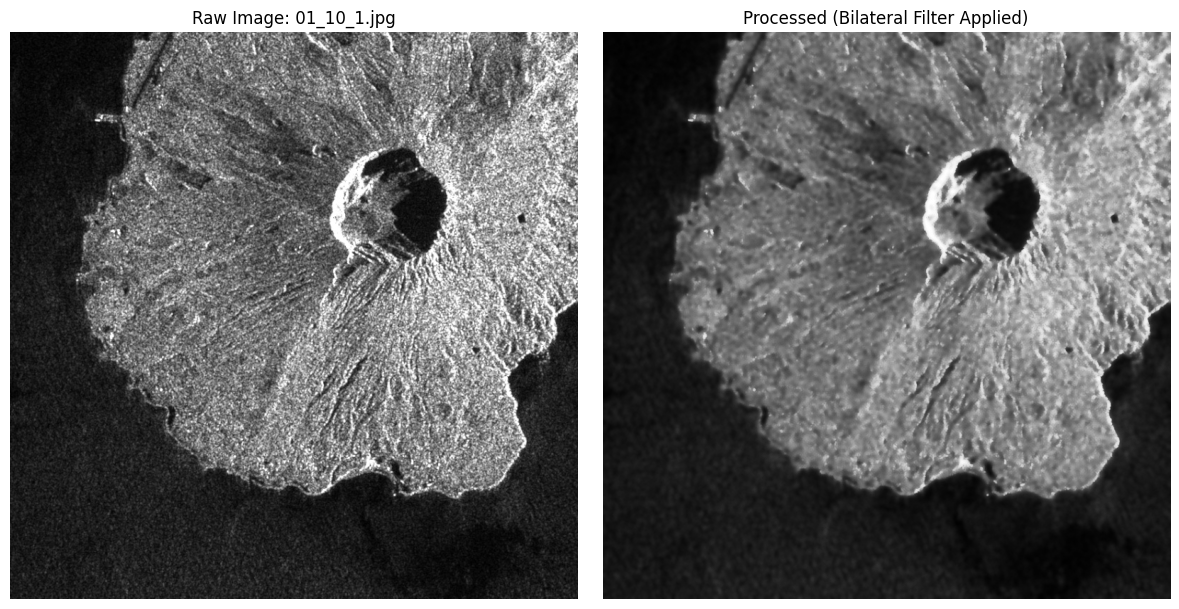

In [4]:
import matplotlib.pyplot as plt

def display_side_by_side(image_name):
    # Define paths based on your folder structure
    raw_path = os.path.join("data/raw", "01_2_17.jpg")
    processed_path = os.path.join("data/processed/", "01_2_17.jpg")
    
    # Check if files exist
    if not os.path.exists(raw_path):
        print(f"Error: Could not find raw image at {raw_path}")
        return
    if not os.path.exists(processed_path):
        print(f"Error: Could not find processed image at {processed_path}. Did you run the preprocessing script?")
        return

    # Read the images in grayscale (since SAR data is single-band radar)
    img_raw = cv2.imread(raw_path, cv2.IMREAD_GRAYSCALE)
    img_processed = cv2.imread(processed_path, cv2.IMREAD_GRAYSCALE)

    # Set up the Matplotlib plot window
    plt.figure(figsize=(12, 6))

    # Left subplot: Raw Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_raw, cmap='gray')
    plt.title(f"Raw Image: {image_name}")
    plt.axis('off')

    # Right subplot: Processed Image
    plt.subplot(1, 2, 2)
    plt.imshow(img_processed, cmap='gray')
    plt.title("Processed (Bilateral Filter Applied)")
    plt.axis('off')

    # Show the window on your screen
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Get the first image name found in your raw folder automatically
    raw_images = [f for f in os.listdir("data/raw") if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if raw_images:
        # Pass the first image to the visualizer
        display_side_by_side(raw_images[0])
    else:
        print("No images found in data/raw to visualize.")


In [1]:
import torch

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("WARNING: CUDA is not active. PyTorch is defaulting to the CPU.")


Is CUDA available? True
Current GPU Device Name: NVIDIA GeForce GTX 1650
CUDA Version: 11.7


## Modeld Training & Tuning

In [2]:
import os
from ultralytics import YOLO

def main():
    # 1. Load the lightweight YOLOv8 Nano model. 
    # 'yolov8n.pt' is highly optimized for 4GB VRAM cards like the GTX 1650.
    model = YOLO("yolov8n.pt")

    # 2. Kick off the training process
    model.train(
        data="dataset.yaml",       # Path to your config file
        epochs=30,                 # 30 epochs is a good portfolio baseline
        imgsz=512,                 # Resizes images to match your preprocessing
        batch=8,                   # Kept at 8 to prevent VRAM crashes on the 1650
        device=0,                  # Device '0' explicitly forces PyTorch to use your GTX 1650
        workers=2,                 # Low CPU worker thread count to prevent memory choke points
        amp=False,                 # Turn Mixed Precision off to keep training stable on older GTX cards
        plots=True                 # Generates loss charts for your resume portfolio
    )

if __name__ == "__main__":
    # Windows requires the training loop to be safely wrapped in a main entry point
    main()


New https://pypi.org/project/ultralytics/8.4.159 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.135  Python-3.10.11 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
yolo\engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=dataset.yaml, epochs=30, patience=50, batch=8, imgsz=512, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, re

In [1]:
import os
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your newly trained custom model weights
# Ensure this path matches your latest run folder
model_path = "runs/detect/train/weights/best.pt"

if not os.path.exists(model_path):
    print(f"Error: Could not find trained weights at {model_path}. Check your runs/detect/ folder.")
else:
    model = YOLO(model_path)

    # 2. Run validation on your validation dataset split
    print("Evaluating model metrics on validation data...")
    metrics = model.val()

    # 3. Print out the core Key Performance Indicators (KPIs)
    print("\n" + "="*40)
    print("      SPACE42 PROJECT SURVEILLANCE METRICS")
    print("="*40)
    print(f"Precision (Confidence of detection):   {metrics.results_dict['metrics/precision(B)']:.4f}")
    print(f"Recall (Ability to find all ships):    {metrics.results_dict['metrics/recall(B)']:.4f}")
    print(f"mAP50 (Accuracy at 0.5 IoU threshold):  {metrics.results_dict['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95 (Strict localization metric): {metrics.results_dict['metrics/mAP50-95(B)']:.4f}")
    print("="*40)


Ultralytics YOLOv8.0.135  Python-3.10.11 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)


Evaluating model metrics on validation data...


Model summary (fused): 168 layers, 3005843 parameters, 0 gradients
val: Scanning D:\Portfolio\Data Science Portfolio\Individual Projects\Automated Maritime Vessel detection system\datase
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 113/113 [00:
                   all       1800       1006      0.793      0.514      0.584      0.221
Speed: 0.2ms preprocess, 4.0ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\val



      SPACE42 PROJECT SURVEILLANCE METRICS
Precision (Confidence of detection):   0.7930
Recall (Ability to find all ships):    0.5139
mAP50 (Accuracy at 0.5 IoU threshold):  0.5843
mAP50-95 (Strict localization metric): 0.2211


In [4]:
# 4. Test prediction on a raw verification image
# Pick any image name from your validation set
test_image_path = "data/processed/images/val/01_7_13.jpg" 

if os.path.exists(test_image_path):
    results = model.predict(source=test_image_path, save=True, conf=0.25)
    print(f"\nVisual inference complete! Saved to: runs/detect/predict/")


## Production Packaging

In [5]:
%%writefile requirements.txt
ultralytics==8.3.0
rasterio>=1.3.0
opencv-python-headless>=4.8.0
numpy>=1.24.0
matplotlib>=3.7.0
pandas>=2.0.0


Writing requirements.txt


In [6]:
%%writefile production_inference.py
import os
import sys
import cv2
import json
from ultralytics import YOLO

def apply_speckle_filter(img):
    # The same edge-preserving radar filter you built in Phase 2
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

def run_production_pipeline(image_path, weights_path="best.pt"):
    if not os.path.exists(image_path):
        print(json.dumps({"error": f"Input image {image_path} not found"}))
        return

    # 1. Load image in grayscale (SAR standard)
    raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # 2. Preprocess: Clean radar noise
    cleaned_img = apply_speckle_filter(raw_img)
    
    # Save a temporary clean image for YOLO to read
    temp_path = "temp_processed.png"
    cv2.imwrite(temp_path, cleaned_img)

    # 3. Load Model and Predict (Forcing CPU for universal cloud compatibility)
    model = YOLO(weights_path)
    results = model.predict(source=temp_path, conf=0.25, verbose=False)
    
    # 4. Extract structured JSON telemetry data 
    output_predictions = []
    for result in results:
        boxes = result.boxes
        for box in boxes:
            coords = box.xyxy[0].tolist() # [xmin, ymin, xmax, ymax]
            conf = float(box.conf[0])
            output_predictions.append({
                "class": "ship",
                "confidence": round(conf, 4),
                "bounding_box": [round(c, 2) for c in coords]
            })

    # Clean up temp file
    if os.path.exists(temp_path):
        os.remove(temp_path)

    # Print clean JSON output to standard output stream
    print(json.dumps({"status": "success", "detections": output_predictions}, indent=2))

if __name__ == "__main__":
    # Allows image path injection via command line arguments
    img_arg = sys.argv[1] if len(sys.argv) > 1 else "test_target.png"
    run_production_pipeline(img_arg)


Writing production_inference.py


In [1]:
%%writefile Dockerfile
# Use a lightweight, official Python image optimized for production
FROM python:3.10-slim

# Install system-level dependencies required by openCV and geospatial libraries
RUN apt-get update && apt-get install -y \
    libgl1 \
    libglx-mesa0 \
    && rm -rf /var/lib/apt/lists/*

# Set up the internal workspace directory inside the container
WORKDIR /app

# Copy and install Python dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy your production script and trained weights file into the image
COPY production_inference.py .
COPY runs/detect/train/weights/best.pt ./best.pt

# Define what command the container runs when it boots up
ENTRYPOINT ["python", "production_inference.py"]


Writing Dockerfile
